In [84]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset
from sklearn.datasets import fetch_california_housing

In [85]:
housing = fetch_california_housing()

In [86]:
df = pd.DataFrame(housing.data, columns=housing.feature_names)

df["Price"] = housing.target

In [87]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [88]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [89]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [90]:
df.shape

(20640, 9)

In [91]:
df.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64

In [92]:
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'Price'],
      dtype='str')

In [93]:
df.corr()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
Price,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


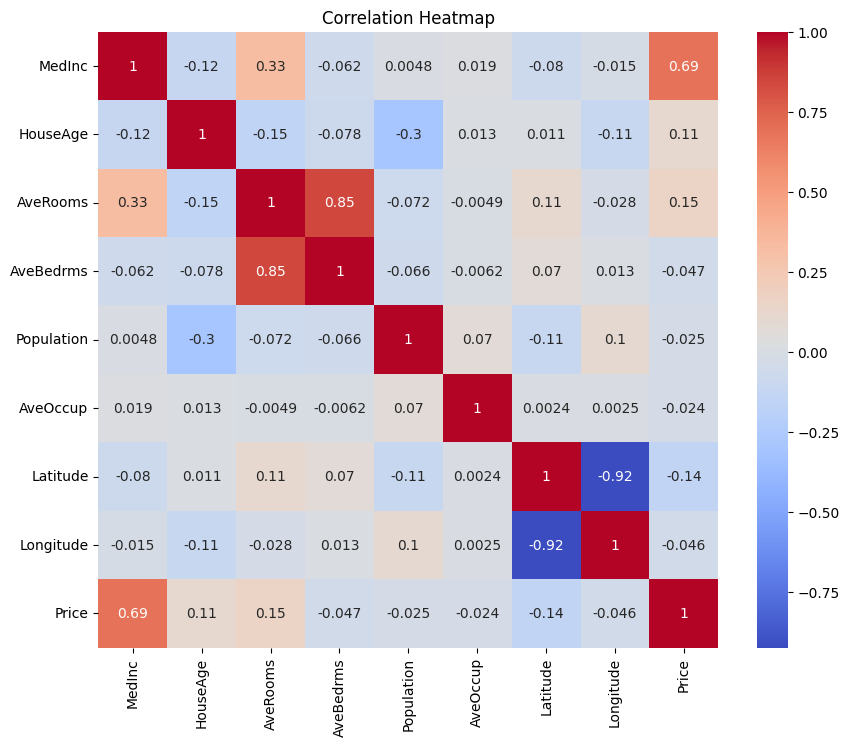

In [94]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

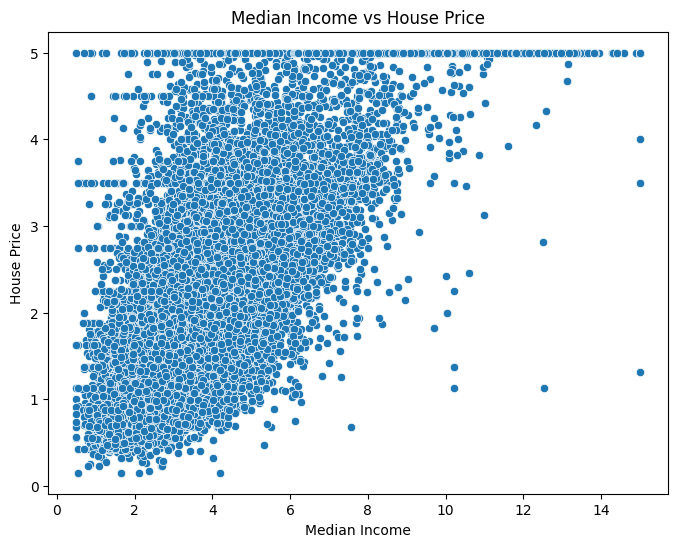

In [95]:
plt.figure(figsize=(8,6))

sns.scatterplot(x=df["MedInc"], y=df["Price"])

plt.title("Median Income vs House Price")
plt.xlabel("Median Income")
plt.ylabel("House Price")

plt.show()

In [96]:
X = df.drop("Price", axis=1)
y = df["Price"]

In [97]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [98]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (16512, 8)
X_test : (4128, 8)
y_train: (16512,)
y_test : (4128,)


In [99]:
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred = lr_model.predict(X_test)

In [100]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)

Mean Absolute Error (MAE): 0.5332001304956555


In [101]:
print(df["Price"].describe())

count    20640.000000
mean         2.068558
std          1.153956
min          0.149990
25%          1.196000
50%          1.797000
75%          2.647250
max          5.000010
Name: Price, dtype: float64


In [102]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)

Mean Squared Error (MSE): 0.5558915986952442


In [103]:
from sklearn.metrics import root_mean_squared_error

rmse = root_mean_squared_error(y_test, y_pred)

print("Root Mean Squared Error (RMSE):", rmse)

Root Mean Squared Error (RMSE): 0.7455813830127763


In [104]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.575787706032451


In [105]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_model.coef_
})

coefficients

,Feature,Coefficient
0,MedInc,0.448675
1,HouseAge,0.009724
2,AveRooms,-0.123323
3,AveBedrms,0.783145
4,Population,-0.000002
5,AveOccup,-0.003526
6,Latitude,-0.419792
7,Longitude,-0.433708


In [106]:
coefficients.sort_values(by="Coefficient", ascending=False)

,Feature,Coefficient
3,AveBedrms,0.783145
0,MedInc,0.448675
1,HouseAge,0.009724
4,Population,-0.000002
5,AveOccup,-0.003526
2,AveRooms,-0.123323
6,Latitude,-0.419792
7,Longitude,-0.433708


In [107]:
print("Intercept:", lr_model.intercept_)

Intercept: -37.02327770606416


In [108]:
y_pred = lr_model.predict(X_test)

In [109]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
0,0.47700,0.719123
1,0.45800,1.764017
2,5.00001,2.709659
3,2.18600,2.838926
4,2.78000,2.604657
5,1.58700,2.011754
6,1.98200,2.645500
7,1.57500,2.168755
8,3.40000,2.740746
9,4.46600,3.915615


In [110]:
residuals = y_test - y_pred

residuals.head()

20046   -0.242123
3024    -1.306017
15663    2.290351
20484   -0.652926
9814     0.175343
Name: Price, dtype: float64

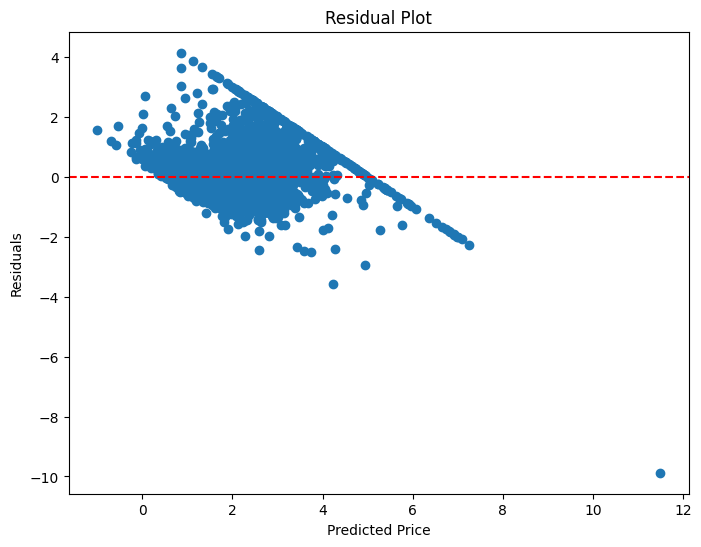

In [111]:
plt.figure(figsize=(8,6))

plt.scatter(y_pred, residuals)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

In [112]:
from sklearn.linear_model import Ridge
ridge = Ridge(alpha=1.0)

In [113]:
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)

In [114]:
from sklearn.metrics import mean_absolute_error

ridge_mae = mean_absolute_error(y_test, ridge_pred)

print("Ridge MAE:", ridge_mae)

Ridge MAE: 0.5332039182571148


In [115]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge MAE :", ridge_mae)
print("Ridge MSE :", ridge_mse)
print("Ridge RMSE:", ridge_rmse)
print("Ridge R²  :", ridge_r2)

Ridge MAE : 0.5332039182571148
Ridge MSE : 0.5558034669932211
Ridge RMSE: 0.7455222779992702
Ridge R²  : 0.5758549611440126


In [116]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [117]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

linear_mae = mean_absolute_error(y_test, y_pred)
linear_mse = mean_squared_error(y_test, y_pred)
linear_rmse = np.sqrt(linear_mse)
linear_r2 = r2_score(y_test, y_pred)

print("Linear MAE :", linear_mae)
print("Linear MSE :", linear_mse)
print("Linear RMSE:", linear_rmse)
print("Linear R²  :", linear_r2)

Linear MAE : 0.5332001304956555
Linear MSE : 0.5558915986952442
Linear RMSE: 0.7455813830127763
Linear R²  : 0.575787706032451


In [118]:
from sklearn.linear_model import Lasso
lasso = Lasso(alpha=1.0)

In [119]:
lasso.fit(X_train, y_train)
lasso_pred = lasso.predict(X_test)

In [120]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lasso_mae = mean_absolute_error(y_test, lasso_pred)
lasso_mse = mean_squared_error(y_test, lasso_pred)
lasso_rmse = np.sqrt(lasso_mse)
lasso_r2 = r2_score(y_test, lasso_pred)

print("Lasso MAE :", lasso_mae)
print("Lasso MSE :", lasso_mse)
print("Lasso RMSE:", lasso_rmse)
print("Lasso R²  :", lasso_r2)

Lasso MAE : 0.7615782541669575
Lasso MSE : 0.9380337514945428
Lasso RMSE: 0.9685214254184276
Lasso R²  : 0.2841671821008396


In [121]:
feature_names = housing.feature_names

for feature, coef in zip(feature_names, lasso.coef_):
    print(f"{feature:15} {coef:.6f}")

MedInc          0.148196
HouseAge        0.005728
AveRooms        0.000000
AveBedrms       0.000000
Population      -0.000008
AveOccup        -0.000000
Latitude        -0.000000
Longitude       -0.000000


In [122]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(random_state=42)

In [123]:
tree.fit(X_train, y_train)
tree_pred = tree.predict(X_test)

In [124]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

tree_mae = mean_absolute_error(y_test, tree_pred)
tree_mse = mean_squared_error(y_test, tree_pred)
tree_rmse = np.sqrt(tree_mse)
tree_r2 = r2_score(y_test, tree_pred)

print("Decision Tree MAE :", tree_mae)
print("Decision Tree MSE :", tree_mse)
print("Decision Tree RMSE:", tree_rmse)
print("Decision Tree R²  :", tree_r2)

Decision Tree MAE : 0.45467918846899225
Decision Tree MSE : 0.495235205629094
Decision Tree RMSE: 0.7037294974840077
Decision Tree R²  : 0.622075845135081


In [125]:
train_pred = tree.predict(X_train)

train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, tree_pred)

print("Training R² :", train_r2)
print("Testing R²  :", test_r2)

Training R² : 1.0
Testing R²  : 0.622075845135081


In [126]:
tree5 = DecisionTreeRegressor(max_depth=5, random_state=42)

tree5.fit(X_train, y_train)

train_pred5 = tree5.predict(X_train)
test_pred5 = tree5.predict(X_test)

print("Training R² :", r2_score(y_train, train_pred5))
print("Testing R² :", r2_score(y_test, test_pred5))

Training R² : 0.6376786573648903
Testing R² : 0.5997321244428706


In [127]:
tree10 = DecisionTreeRegressor(max_depth=10, random_state=42)

tree10.fit(X_train, y_train)

train_pred10 = tree10.predict(X_train)
test_pred10 = tree10.predict(X_test)

print("Training R² :", r2_score(y_train, train_pred10))
print("Testing R²  :", r2_score(y_test, test_pred10))

Training R² : 0.8347775350789697
Testing R²  : 0.6829476865157171


In [128]:
tree8 = DecisionTreeRegressor(max_depth=8, random_state=42)

tree8.fit(X_train, y_train)

pred = tree8.predict(X_test)

print(r2_score(y_test, pred))

0.6779284983766045


In [129]:
from sklearn.model_selection import GridSearchCV

In [130]:
param_grid = {
    "max_depth": [5, 8, 10, 12, 15]
}

In [131]:
grid = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="r2"
)

In [132]:
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 8, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parame

In [133]:
print(grid.best_params_)
print(grid.best_score_)

{'max_depth': 8}
0.6964266932502005


In [134]:
best_tree = grid.best_estimator_

best_pred = best_tree.predict(X_test)

print("Best Test R² :", r2_score(y_test, best_pred))
print("Best Test MAE:", mean_absolute_error(y_test, best_pred))
print("Best Test RMSE:", np.sqrt(mean_squared_error(y_test, best_pred)))

Best Test R² : 0.6779284983766045
Best Test MAE: 0.44816862399364304
Best Test RMSE: 0.6496502038503689


In [135]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(random_state=42)

In [136]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest MAE :", mean_absolute_error(y_test, rf_pred))
print("Random Forest MSE :", mean_squared_error(y_test, rf_pred))
print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("Random Forest R²  :", r2_score(y_test, rf_pred))

Random Forest MAE : 0.32754256845930246
Random Forest MSE : 0.2553684927247781
Random Forest RMSE: 0.5053399773665033
Random Forest R²  : 0.8051230593157366


In [137]:
train_pred_rf = rf.predict(X_train)

print("Training R² :", r2_score(y_train, train_pred_rf))
print("Testing R²  :", r2_score(y_test, rf_pred))

Training R² : 0.9735726320302575
Testing R²  : 0.8051230593157366


In [138]:
from sklearn.ensemble import GradientBoostingRegressor
gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)

In [139]:
print("Gradient Boosting MAE :", mean_absolute_error(y_test, gb_pred))
print("Gradient Boosting MSE :", mean_squared_error(y_test, gb_pred))
print("Gradient Boosting RMSE:", np.sqrt(mean_squared_error(y_test, gb_pred)))
print("Gradient Boosting R²  :", r2_score(y_test, gb_pred))

Gradient Boosting MAE : 0.3716425690425596
Gradient Boosting MSE : 0.2939973248643864
Gradient Boosting RMSE: 0.5422152016168362
Gradient Boosting R²  : 0.7756446042829697


In [140]:
train_pred_gb = gb.predict(X_train)

print("Training R² :", r2_score(y_train, train_pred_gb))
print("Testing R²  :", r2_score(y_test, gb_pred))

Training R² : 0.8048978817773166
Testing R²  : 0.7756446042829697


In [141]:
param_grid = {
    "learning_rate": [0.01, 0.05, 0.1],
    "n_estimators": [100, 200],
    "max_depth": [2, 3, 4]
}

In [142]:
from sklearn.model_selection import GridSearchCV

grid_gb = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_gb.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.05, ...], 'max_depth': [2, 3, ...], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : th

In [143]:
print(grid_gb.best_params_)
print(grid_gb.best_score_)

{'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200}
0.8216761946323581


In [144]:
best_gb = grid_gb.best_estimator_

best_pred = best_gb.predict(X_test)

print("Best Gradient Boosting Test R² :", r2_score(y_test, best_pred))
print("Best Gradient Boosting MAE      :", mean_absolute_error(y_test, best_pred))
print("Best Gradient Boosting RMSE     :", np.sqrt(mean_squared_error(y_test, best_pred)))

Best Gradient Boosting Test R² : 0.8185494799226947
Best Gradient Boosting MAE      : 0.3274007588412409
Best Gradient Boosting RMSE     : 0.48762115480748114


In [145]:
train_pred = best_gb.predict(X_train)

print("Training R² :", r2_score(y_train, train_pred))
print("Testing R²  :", r2_score(y_test, best_pred))

Training R² : 0.8719626864937611
Testing R²  : 0.8185494799226947


In [146]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [147]:
import xgboost
print(xgboost.__version__)

3.3.0


In [148]:
from xgboost import XGBRegressor

xgb = XGBRegressor(random_state=42)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

print("XGBoost MAE :", mean_absolute_error(y_test, xgb_pred))
print("XGBoost MSE :", mean_squared_error(y_test, xgb_pred))
print("XGBoost RMSE:", np.sqrt(mean_squared_error(y_test, xgb_pred)))
print("XGBoost R²  :", r2_score(y_test, xgb_pred))

XGBoost MAE : 0.31074241395526386
XGBoost MSE : 0.21404356860001178
XGBoost RMSE: 0.46264842872316314
XGBoost R²  : 0.8366589575055071


In [149]:
train_pred_xgb = xgb.predict(X_train)

print("Training R² :", r2_score(y_train, train_pred_xgb))
print("Testing R²  :", r2_score(y_test, xgb_pred))

Training R² : 0.943122283030685
Testing R²  : 0.8366589575055071


In [150]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

importance

,Feature,Importance
0,MedInc,0.479923
5,AveOccup,0.158646
7,Longitude,0.108794
6,Latitude,0.096155
1,HouseAge,0.065551
2,AveRooms,0.042610
3,AveBedrms,0.025066
4,Population,0.023254


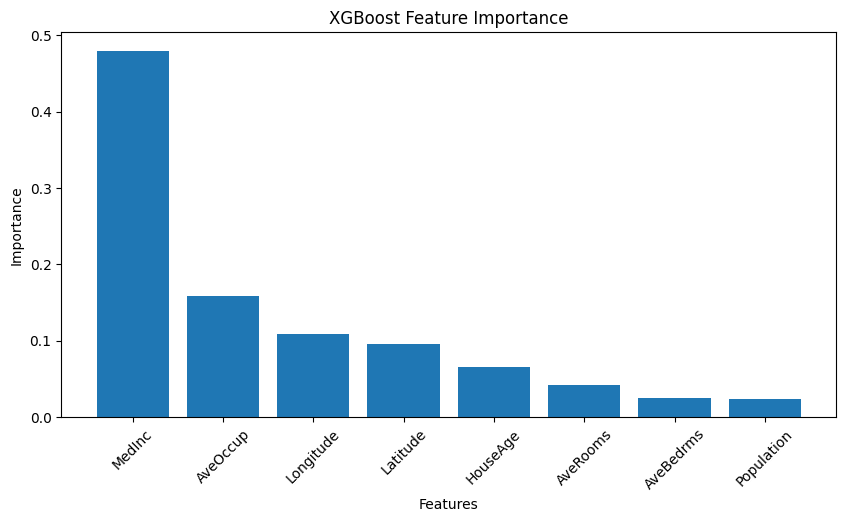

In [151]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(importance["Feature"], importance["Importance"])

plt.xticks(rotation=45)

plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("XGBoost Feature Importance")

plt.show()

In [152]:
%pip install shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [153]:
import shap

print(shap.__version__)

0.52.0


In [154]:
explainer = shap.TreeExplainer(xgb)

In [155]:
shap_values = explainer(X_test)
explainer.shap_values(X_test)
explainer(X_test)

.values =
array([[-5.22386134e-01,  6.38551358e-03, -9.01896581e-02, ...,
        -2.09764466e-01, -5.05410612e-01, -1.64787009e-01],
       [-4.02794212e-01,  1.21967075e-03, -1.42722026e-01, ...,
        -5.45611940e-02, -6.01105392e-01, -9.11172107e-02],
       [ 5.38206100e-02,  5.33610165e-01, -1.77591130e-01, ...,
         8.08275998e-01,  3.48831862e-02,  1.56380630e+00],
       ...,
       [ 2.16202569e+00,  2.59823864e-03,  1.23985335e-01, ...,
         2.23301444e-02, -1.07617080e-01,  8.58448386e-01],
       [-3.74183804e-01, -1.47595946e-02, -8.20822343e-02, ...,
        -4.04663198e-02, -7.55895853e-01, -1.11038923e-01],
       [-1.51493341e-01, -4.72077131e-02, -1.81495935e-01, ...,
        -3.58867168e-01,  2.78503537e-01, -1.72791758e-03]],
      shape=(4128, 8), dtype=float32)

.base_values =
array([2.071854, 2.071854, 2.071854, ..., 2.071854, 2.071854, 2.071854],
      shape=(4128,), dtype=float32)

.data =
array([[   1.6812    ,   25.        ,    4.19220056, ...,    

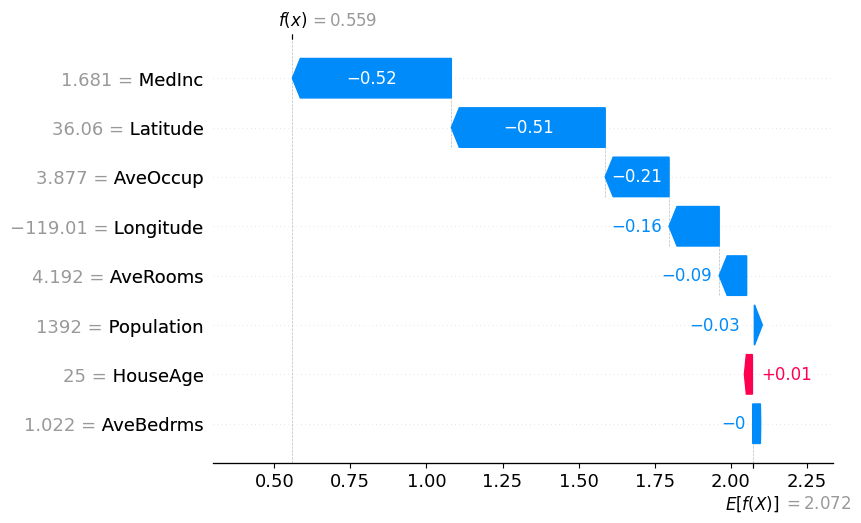

In [156]:
shap.plots.waterfall(shap_values[0])

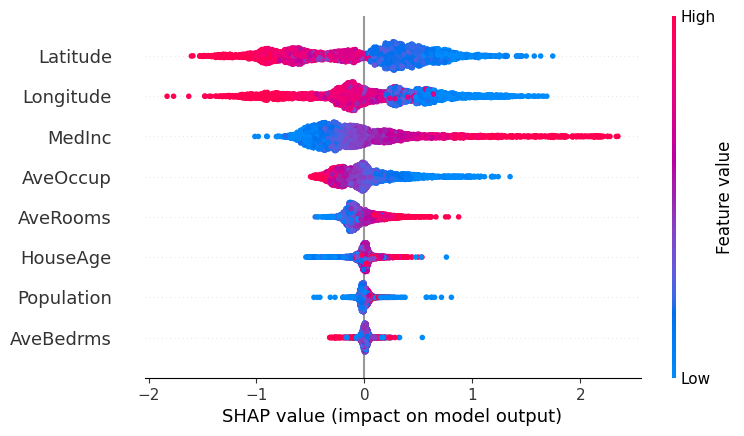

In [157]:
shap.plots.beeswarm(shap_values)

In [158]:
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

pipeline = Pipeline([
    ("model", XGBRegressor(random_state=42))
])

In [159]:
pipeline.fit(X_train, y_train)
pipeline_pred = pipeline.predict(X_test)

print("Pipeline R² :", r2_score(y_test, pipeline_pred))

Pipeline R² : 0.8366589575055071


In [160]:
import joblib

In [161]:
joblib.dump(xgb, "house_price_xgboost.pkl")

['house_price_xgboost.pkl']

In [162]:
import os

print(os.listdir())

['house_price_prediction.ipynb', 'house_price_xgboost.pkl', 'overfitting_underfitting.ipynb']


In [163]:
loaded_model = joblib.load("house_price_xgboost.pkl")

In [164]:
loaded_pred = loaded_model.predict(X_test)

print("Loaded Model R² :", r2_score(y_test, loaded_pred))

Loaded Model R² : 0.8366589575055071


In [165]:
from sklearn.model_selection import cross_val_score
from xgboost import XGBRegressor

xgb_cv = XGBRegressor(random_state=42)

cv_scores = cross_val_score(
    xgb_cv,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("Cross Validation Scores:", cv_scores)
print("Average R² Score:", cv_scores.mean())

Cross Validation Scores: [0.54932537 0.70386605 0.72793222 0.66010998 0.64280305]
Average R² Score: 0.656807334342391


In [166]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

xgb = XGBRegressor(random_state=42)

In [168]:
param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 5, 7, 10],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.8, 0.9, 1.0],
    "colsample_bytree": [0.8, 0.9, 1.0]
}

In [169]:
from sklearn.model_selection import RandomizedSearchCV

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=20,
    scoring="r2",
    cv=5,
    random_state=42,
    n_jobs=-1
)

In [170]:
random_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.8, 0.9, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used he

In [171]:
print("Best Parameters:")
print(random_search.best_params_)

Best Parameters:
{'subsample': 0.9, 'n_estimators': 500, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.8}


In [172]:
print("Best Cross Validation R² Score:")
print(random_search.best_score_)

Best Cross Validation R² Score:
0.8475861327001433


In [173]:
best_xgb = random_search.best_estimator_

best_pred = best_xgb.predict(X_test)

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

print("Test R² :", r2_score(y_test, best_pred))
print("MAE :", mean_absolute_error(y_test, best_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, best_pred)))

Test R² : 0.8521345669249606
MAE : 0.2846398862079225
RMSE : 0.44018654122202616


In [174]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

In [175]:
train_sizes, train_scores, test_scores = learning_curve(
    estimator=best_xgb,
    X=X_train,
    y=y_train,
    cv=5,
    scoring="r2",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

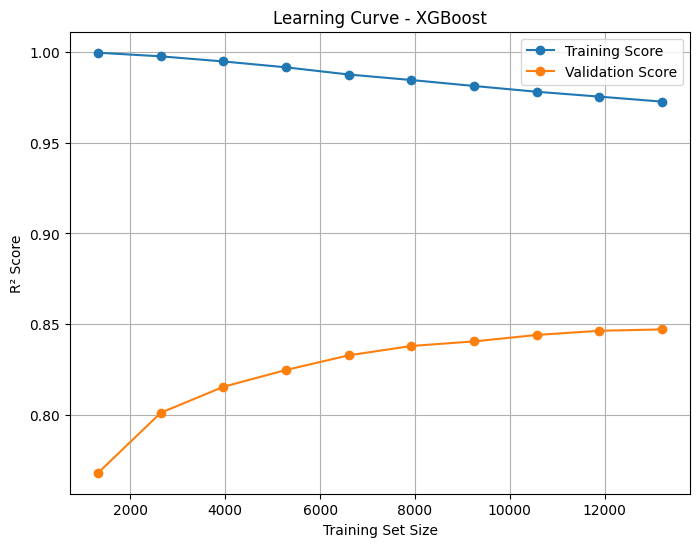

In [176]:
# Calculate average scores across the 5 folds
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

# Plot the learning curve
plt.figure(figsize=(8,6))

plt.plot(train_sizes, train_mean, marker='o', label="Training Score")
plt.plot(train_sizes, test_mean, marker='o', label="Validation Score")

plt.title("Learning Curve - XGBoost")
plt.xlabel("Training Set Size")
plt.ylabel("R² Score")
plt.legend()
plt.grid(True)

plt.show()